- 第一是对 llm 原理的理解，第二另外一个很大的 topic：Mechanistic Interpretability
    - 更深入地理解 attention，也更深入的理解 icl（in-context learning）
    - 提取、处理、加工
- https://www.youtube.com/watch?v=pC4zRb_5noQ
- https://gemini.google.com/app/a813fb1c0de13978

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

- 在 LLM 的 Transformer 架构中（Multi-layer Multi-heads），某一层的 Multi-Head Attention (MHA) 里的 $\mathbf{q}^T \mathbf{k}$（即 Query 和 Key 的点积，通常称为 Attention Logits 或 Pre-softmax Attention Scores）是决定模型“看哪里”（attend to）的核心步骤。
- attention score matrix 一定是下三角的（causal attention）
    - 当前 token 的 query 只能跟 past tokens（以及 self） 的 key 做内积计算，不可跟 future tokens（的 keys） 做内积计算

- causal mask（0-1 matrix）
```
    K1  K2  K3  K4 (Keys)
Q1    1   0   0   0
Q2    1   1   0   0
Q3    1   1   1   0
Q4    1   1   1   1
(Queries)
```

In [4]:
import torch 
torch.tril(torch.ones(4, 4))

tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])

### “注意力汇聚点” (Attention Sinks)

> 在绝大多数层（尤其是中后层），你会发现当前的 $\mathbf{q}_t$ 与序列的第一个 Token（BOS, Beginning of Sentence） 的 $\mathbf{k}_0$ 计算出的点积 $\mathbf{q}_t^T \mathbf{k}_0$ 往往异常大（即非常显著的正值）。

- 即使第一个 Token（通常是 `<|endoftext|>` 或 `<s>`）在语义上没有任何实际意义，它依然会获得极高的注意力分数。
- 分析原因：
    - Softmax 的归一化压力： Softmax 函数 $\text{softmax}(\mathbf{x})_i = \frac{e^{x_i}}{\sum e^{x_j}}$ 强迫所有注意力权重之和为 1。
    - “无事可做”时的卸载机制： 当当前的 Token 不需要关注上下文中的任何具体信息（例如处理停用词或简单的局部语法）时，模型需要一个“**垃圾回收站**”来以此卸载多余的概率质量。如果它不关注某一个特定 Token，概率就会平均分散，导致高熵（High Entropy），这通常不是模型想要的。
        - $PPL=\exp(CrossEntropy)$
        - Softmax 强迫归一化（**强制性**）。当当前词（Query）发现前面的词（Keys）没有一个是它特别想关注的时，它不会“什么都不看”，而是把这一票投给“第一个人”（BOS）。这不会影响结果，因为 Value 矩阵通常会把这个位置的输出屏蔽掉或作为偏置项处理。
    - BOS 的位置优势： 第一个 Token 对所有后续 Token 都是可见的，且位置固定，因此模型倾向于将其训练成一个通用的“**默认关注点**”（Sink）。

### PTH (Previous Token Head)

- 在 Induction Head 之前的层（或同一层的其他头），有一个Previous Token Head。
- 它的作用很简单：把前一个 Token 的信息“搬运”到当前 Token 的残差流（Residual Stream）里。
    - 结果：在历史序列中，当模型处理到 Token B 时，Token B 的向量里其实暗中包含了一个副本——A 的信息。
    - Token B 的潜台词变成了：“我是 B，而且我紧跟在 A 后面”。
- PTH 不负责预测下一个词，它只负责整理上下文信息。它总是盯着 $t-1$ 看，不管 $t-1$ 是什么。

### 归纳头模式 (Induction Heads) 的激活

在模型的特定层（通常是模型深度的 1/3 到 1/2 处），会出现明显的“归纳”模式。（复读，copying mechanism，cursor 中的 tab 补全，一种 powerful 的模式识别匹配（matching））
- 假设当前的 Query 是 Token `A`。
- $\mathbf{q}^T \mathbf{k}$ 会在上下文中紧跟在上一个 A 出现位置之后的那个 Token B 上产生极大的值。
- 公式化： 如果序列是 `... A B ... A` (当前)，模型会极力关注 B。

原因：
- In-Context Learning (ICL) 的核心机制： 这是 LLM 具备“从上下文中学习”能力的关键电路。模型通过观察 A -> B 的历史模式，预测当前 A 后面也应该接 B。
- QK 电路的特化： 这种头部的 $\mathbf{W}_Q$ 和 $\mathbf{W}_K$ 矩阵被训练为寻找“前序 Token 的匹配项”，而不是语义相似项。
    - $\text{Score} = (\mathbf{W}_Q \cdot \text{Token}_A)^T (\mathbf{W}_K \cdot \text{Token}_B)$
    - $\mathbf{W}_Q$ 和 $\mathbf{W}_K$ 被训练成了什么？
        - $\mathbf{W}_Q$ (作用于当前 A)：它将 A 映射到一个特定的子空间。在这个子空间里，它的向量方向代表：“呼叫所有前缀是 A 的 Token！”
        - $\mathbf{W}_K$ (作用于历史 B)：它不是去读 B 本身的内容（那没用）。它是去读 B 身上那个**“我紧跟在 A 后面”**的标签（即第一步搬运过来的 A 的信息）。它将这个标签映射到同一个子空间，向量方向代表：“我就是前缀为 A 的 Token。”
    - $\mathbf{W}_K$ 实际上是在提取 Token B 残差流中关于 Token A 的那部分历史信息。直观理解：$\mathbf{W}_K$ 变成了一个**“前缀提取器”，而不是“内容提取器”**。 
notes：
- 普通的自然语言句子不一定能强烈激活 Induction Head。要让 Induction Head 现原形，我们需要使用重复的随机序列（Repeated Random Tokens），这是 Mechanistic Interpretability 领域的标准探针。

检测到最强的 Previous Token Head 位于: Layer 4, Head 11
Previous Token Score: 0.9995


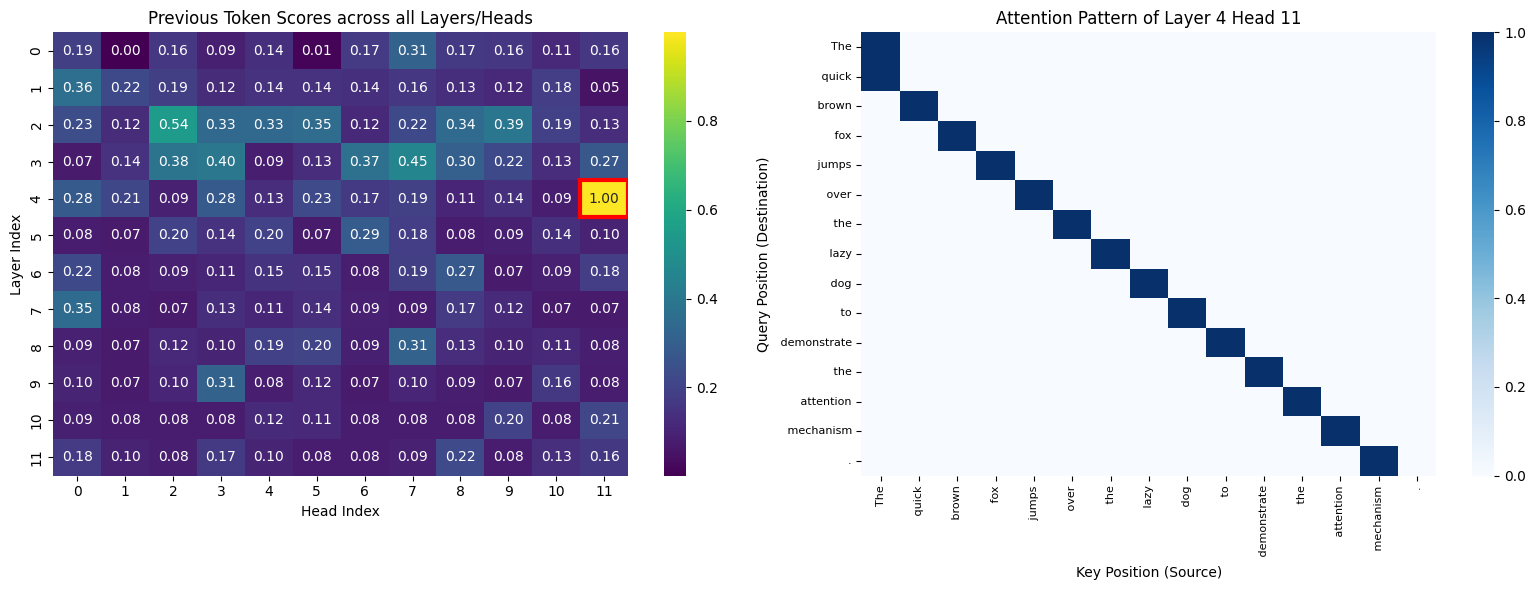

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import GPT2LMHeadModel, GPT2Tokenizer

model_name = "gpt2"
model = GPT2LMHeadModel.from_pretrained(model_name, attn_implementation="eager")
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model.eval()

text = "The quick brown fox jumps over the lazy dog to demonstrate the attention mechanism."
inputs = tokenizer(text, return_tensors="pt")
# 15 tokens
tokens = [tokenizer.decode([t]) for t in inputs['input_ids'][0]]

# 2. 前向传播并获取 Attention
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)
    # attentions 结构: tuple of 12 layers, each is [batch, num_heads, seq_len, seq_len]
    # 12 * [1, 12, 15, 15]
    attentions = outputs.attentions 

# 3. 核心探测算法：寻找 Previous Token Head
# 我们要计算每个 Head 在 "上一位置 (token index - 1)" 的平均注意力权重
num_layers = len(attentions)
num_heads = attentions[0].shape[1]
seq_len = inputs['input_ids'].shape[1]

# 存储分数的矩阵 [Layer, Head]
prev_token_scores = np.zeros((num_layers, num_heads))

for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        # 获取当前 Layer, Head 的注意力矩阵 (去掉 batch 维度)
        attn_matrix = attentions[layer_idx][0, head_idx, :, :].numpy()
        
        # 提取 "Previous Token" 对角线 (offset=-1)
        # 注意：第0个 token 没有 previous，所以从第1行开始看
        # diag_vals 是每个 token 对其前一个 token 的注意力值
        diag_vals = np.diag(attn_matrix, k=-1)
        
        # 计算平均分数 (简单的平均值)
        score = np.mean(diag_vals)
        prev_token_scores[layer_idx, head_idx] = score

# 4. 找出最强的 Previous Token Head
best_idx = np.unravel_index(np.argmax(prev_token_scores), prev_token_scores.shape)
best_layer, best_head = best_idx
print(f"检测到最强的 Previous Token Head 位于: Layer {best_layer}, Head {best_head}")
print(f"Previous Token Score: {prev_token_scores[best_layer, best_head]:.4f}")

# 5. 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 图 1: 全局热力图 (寻找亮点)
sns.heatmap(prev_token_scores, ax=axes[0], cmap="viridis", annot=True, fmt=".2f")
axes[0].set_title("Previous Token Scores across all Layers/Heads")
axes[0].set_xlabel("Head Index")
axes[0].set_ylabel("Layer Index")
# 高亮最强的那个
axes[0].add_patch(plt.Rectangle((best_head, best_layer), 1, 1, fill=False, edgecolor='red', lw=3))

# 图 2: 冠军 Head 的注意力模式
best_attn_matrix = attentions[best_layer][0, best_head, :, :].numpy()
sns.heatmap(best_attn_matrix, ax=axes[1], cmap="Blues", cbar=True)
axes[1].set_title(f"Attention Pattern of Layer {best_layer} Head {best_head}")
axes[1].set_xlabel("Key Position (Source)")
axes[1].set_ylabel("Query Position (Destination)")

# 调整标签以显示 Token
tick_locs = np.arange(len(tokens)) + 0.5
axes[1].set_xticks(tick_locs)
axes[1].set_xticklabels(tokens, rotation=90, fontsize=8)
axes[1].set_yticks(tick_locs)
axes[1].set_yticklabels(tokens, rotation=0, fontsize=8)

plt.tight_layout()

In [13]:
len(tokens), len(attentions), attentions[0].shape

(15, 12, torch.Size([1, 12, 15, 15]))

### 位置局部性与 RoPE 的衰减 (Local Bias & Distance Decay)

> 在对角线附近（即 $k$ 的位置紧邻 $q$ 的位置），$\mathbf{q}^T \mathbf{k}$ 的值通常较大；随着距离 $|pos_q - pos_k|$ 的增加，点积值的幅度通常呈现震荡衰减的趋势。

- 语言的局部性原理： 自然语言有很强的局部依赖（Local Dependency），如短语结构、形容词修饰名词等，通常只涉及附近的词。
- RoPE (Rotary Positional Embedding) 的数学特性：RoPE 通过旋转向量来编码位置。对于相对距离 $d$，$\mathbf{q}^T \mathbf{k}$ 的主要项包含 $\cos(d\theta)$。高频分量（$\theta$ 较大）旋转极快，导致远距离的 Token 点积相互抵消（期望趋近于 0），从而产生自然的远程衰减 (Long-term Decay) 效果，使模型天然倾向于关注近距离信息。

### 稀疏性与重尾分布 (Sparsity & Heavy-tailedness)

> 对于同一个 Query，它与序列中绝大多数 Key 的点积 $\mathbf{q}^T \mathbf{k}$ 都在 0 附近或者是负数，只有极少数几个 Key 会产生显著的正值。

- 高维空间的正交性： 在高维空间（如 $d_{head}=128$）中，随机选取的两个向量大概率是近似正交的（点积接近 0）。
- 训练目标的判别性： 模型为了降低 Cross-Entropy Loss，必须做出“确信”的预测。这反向传播要求 Attention 机制必须非常“挑剔”，即 $\mathbf{q}$ 必须与特定的 $\mathbf{k}$ 高度对齐（大点积），而与无关的 $\mathbf{k}$ 保持正交或负相关，以便在 Softmax 后形成尖锐的概率分布（Sharp Distribution）。

### 层级功能的差异 (Layer-wise Specialization)

| 层级 | $\mathbf{q}^T \mathbf{k}$ 的主要模式 | 原因分析 |
| :--- | :--- | :--- |
| **浅层 (Early Layers)** | **局部关注**：主要关注前 1-3 个 Token。 | 负责构建 n-gram 特征和局部句法结构。 |
| **中层 (Middle Layers)** | **归纳头 (Induction) & 语义检索**：关注远处的特定 Token。 | 负责长距离依赖处理和 In-Context Learning，提取语义关系。 |
| **深层 (Late Layers)** | **平滑或特定任务**：有时会出现均匀分布或仅关注特殊的“结束符”。 | 此时语义已高度抽象，主要负责微调输出分布或为下个 Token 的生成做最后的置信度校准。 |

In [1]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer

# =================配置区域=================
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
# 为了演示Induction Head，我们需要一段包含重复模式的文本
# 这里模拟了一段典型的上下文学习（In-Context Learning）输入
INPUT_TEXT = (
    "<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n"
    "<|im_start|>user\n"
    "Input: Apple. Output: Red.\n"
    "Input: Banana. Output: Yellow.\n"
    "Input: Apple. Output:"  # 此时模型应该去关注前面的 'Red'
)

/home/zhangchunhui/miniconda3/envs/verl/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/zhangchunhui/miniconda3/envs/verl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# # =========================================

# def visualize_qwen_attention():
#     print(f"正在加载模型: {MODEL_NAME} ...")
#     tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    
#     # 注意：必须设置 attn_implementation="eager" 才能通过 output_attentions=True 拿到权重
#     # Flash Attention 模式下通常无法返回中间的注意力矩阵
#     model = AutoModelForCausalLM.from_pretrained(
#         MODEL_NAME, 
#         device_map="cuda:1", 
#         torch_dtype="auto",
#         trust_remote_code=True,
#         attn_implementation="eager", 
#         output_attentions=True
#     )

#     inputs = tokenizer(INPUT_TEXT, return_tensors="pt").to(model.device)
#     input_ids = inputs["input_ids"][0]
#     tokens = [tokenizer.decode([t]) for t in input_ids]
    
#     # 稍微缩短过长的token显示，防止图表乱码
#     display_tokens = [t.replace("Input", "In").replace("Output", "Out").strip() for t in tokens]
#     # 处理特殊字符显示
#     display_tokens = [f"_{t}_" if not t else t for t in display_tokens]

#     print("正在进行前向传播...")
#     with torch.no_grad():
#         outputs = model(**inputs)
    
#     # attentions 结构: tuple of (batch, num_heads, seq_len, seq_len)
#     # 共有 num_layers 个 tuple 元素
#     attentions = outputs.attentions 
#     num_layers = len(attentions)
#     num_heads = attentions[0].shape[1]
    
#     print(f"捕获到注意力权重。层数: {num_layers}, 头数: {num_heads}")
#     print("正在自动寻找特征明显的 Head (Sink, Local, Induction)...")

#     # --- 自动寻找特征 Head 的简单启发式算法 ---
    
#     # 1. 寻找 Attention Sink (关注首个Token)
#     # 策略：计算所有 Token 对 Index 0 的平均注意力权重
#     sink_scores = []
#     for layer in range(num_layers):
#         attn = attentions[layer][0].cpu().float().numpy() # (heads, seq, seq)
#         # 取每个头对第0列的平均关注度 (排除第0行本身)
#         avg_attn_to_bos = np.mean(attn[:, 1:, 0], axis=1)
#         for h_idx, score in enumerate(avg_attn_to_bos):
#             sink_scores.append((layer, h_idx, score))
    
#     # 2. 寻找 Local / RoPE Pattern (关注对角线)
#     # 策略：计算对角线及相邻元素的权重占比
#     local_scores = []
#     for layer in range(num_layers):
#         attn = attentions[layer][0].cpu().float().numpy()
#         scores = []
#         for h in range(num_heads):
#             # 提取对角线元素 (self-attention) 和 偏移1的对角线 (prev token)
#             diag = np.diagonal(attn[h])
#             diag_1 = np.diagonal(attn[h], offset=-1)
#             # 简单的局部性分数
#             score = np.mean(diag) + np.mean(diag_1)
#             scores.append(score)
#         for h_idx, score in enumerate(scores):
#             local_scores.append((layer, h_idx, score))

#     # 3. 寻找 Induction Head (归纳头)
#     # 策略：在最后一个 "Apple" (Query) 处，是否强烈关注 第一次出现的 "Red" (Key)
#     # 这里的 indices 需要根据 INPUT_TEXT 硬编码或动态查找
#     # 简单起见，我们找中深层中“关注距离较远且特定的某个前文Token”的头
#     # 这里我们直接选取 sink 和 local 分数较低，但最大值很高的头（稀疏/特化头）作为候选
    
#     # 排序取最佳
#     best_sink = sorted(sink_scores, key=lambda x: x[2], reverse=True)[0]
#     best_local = sorted(local_scores, key=lambda x: x[2], reverse=True)[0]
    
#     # 手动指定一个典型的中层头用于展示 Induction/Semantic (通常在层数的一半左右)
#     # 如果想看特定 Induction，通常在 Layer 10-20 之间
#     induction_candidate = (num_layers // 2, 0) 

#     # --- 绘图 ---
#     fig, axes = plt.subplots(1, 3, figsize=(24, 8))
#     heads_to_plot = [
#         ("Attention Sink Effect", best_sink[0], best_sink[1]),
#         ("Local / RoPE Decay", best_local[0], best_local[1]),
#         ("Sparse / Induction (Mid Layer)", induction_candidate[0], induction_candidate[1])
#     ]

#     for ax, (title, layer, head) in zip(axes, heads_to_plot):
#         attn_map = attentions[layer][0, head].cpu().float().numpy()
        
#         # 使用 Log scale 可以让微小的非零值也显示出来，但原始概率图更能体现 Sink 的统治力
#         # 这里直接画原始概率
#         sns.heatmap(
#             attn_map, 
#             xticklabels=display_tokens, 
#             yticklabels=display_tokens,
#             cmap="viridis", 
#             square=True, 
#             cbar=True,
#             ax=ax,
#             vmin=0.0, vmax=1.0 # 固定量程以便对比
#         )
#         ax.set_title(f"{title}\nLayer {layer}, Head {head}")
#         ax.set_xlabel("Key (Source)")
#         ax.set_ylabel("Query (Target)")
        
#         # 将 x轴标签旋转，防止重叠
#         plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

#     plt.tight_layout()
#     plt.show()
#     print(f"绘制完成。")
#     print(f"Sink Head: Layer {best_sink[0]}, Head {best_sink[1]}")
#     print(f"Local Head: Layer {best_local[0]}, Head {best_local[1]}")

正在加载模型: Qwen/Qwen2.5-3B-Instruct ...


`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading checkpoint shards: 100%|████████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.36s/it]


正在进行前向传播...
捕获到注意力权重。层数: 36, 头数: 16
正在自动寻找特征明显的 Head (Sink, Local, Induction)...


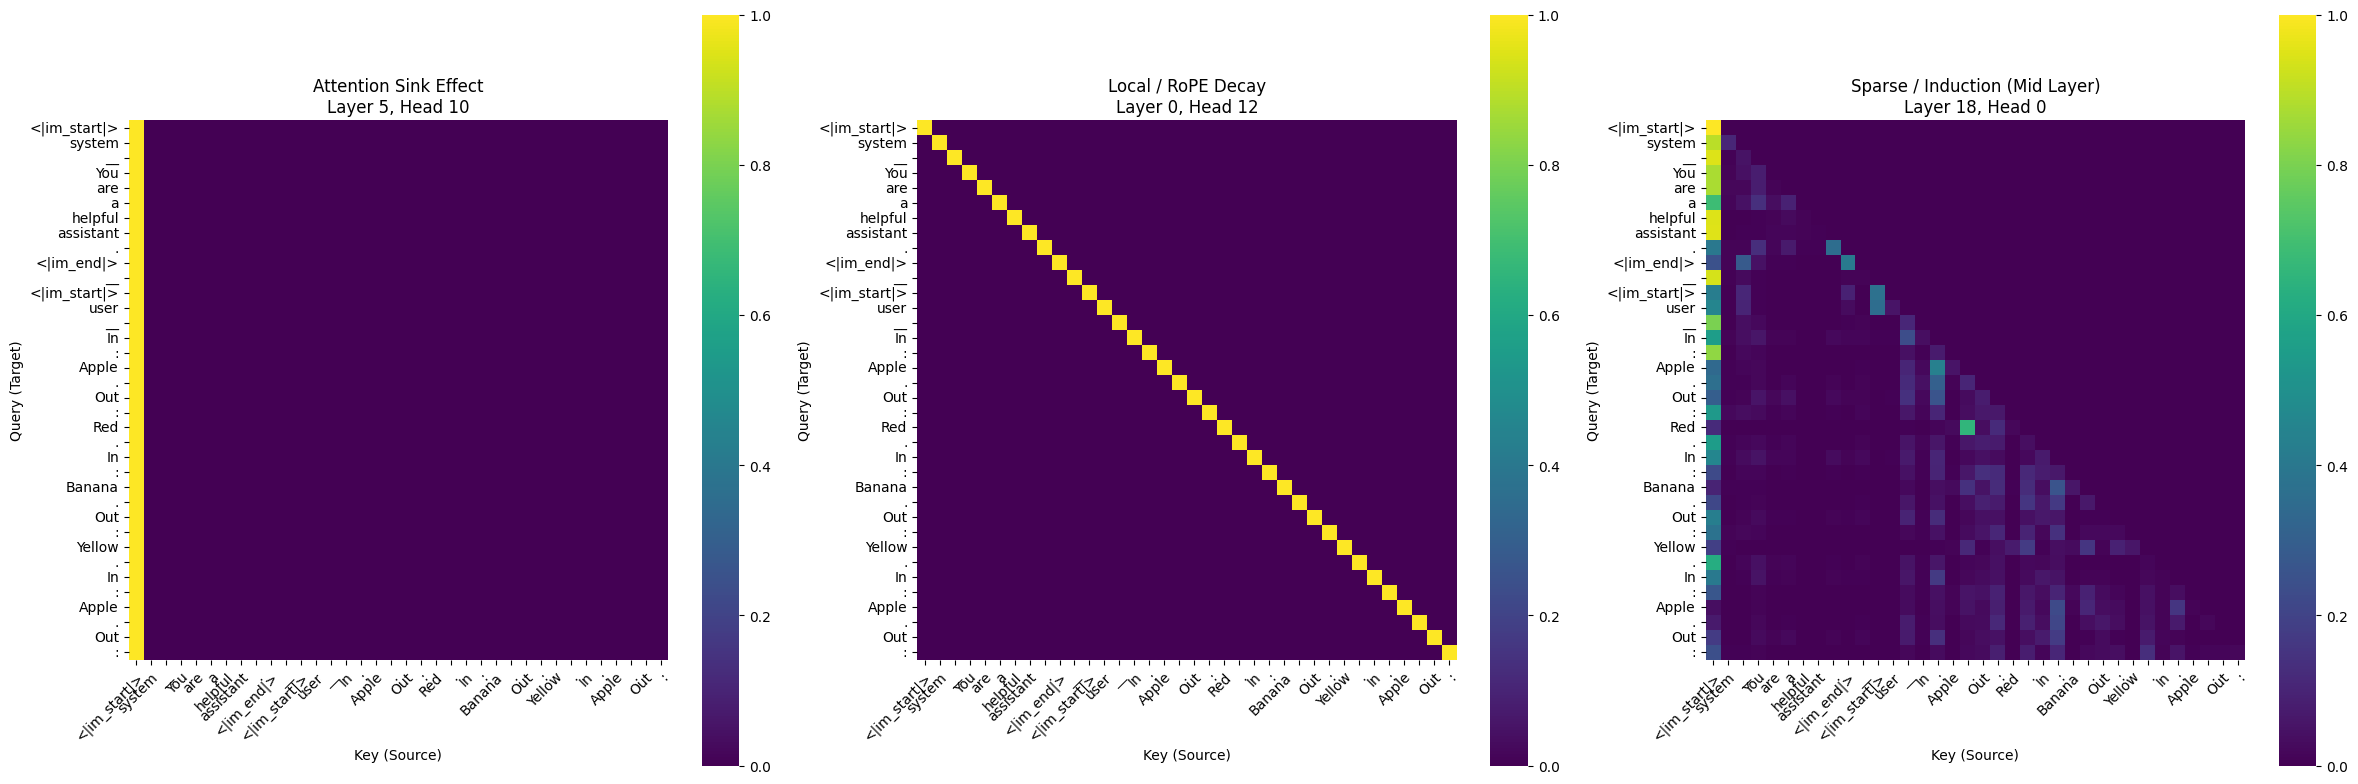

绘制完成。
Sink Head: Layer 5, Head 10
Local Head: Layer 0, Head 12


In [3]:
# visualize_qwen_attention()

In [1]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer

# ================= 1. 构造诱发 Induction 的数据 =================
# 我们构造一个 "Harry Potter" 风格的重复序列
# 模式：Context -> ... [Repeat Context] -> Target
# Induction Head 应该在遇到第二个 "Harry" 时，强烈关注第一个 "Harry" 后面的 "Potter"
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

# 这是一个更强的测试用例，包含完全重复的序列
INPUT_TEXT = (
    "The secret code is 1234. The magic word is abracadabra. "  # Context A
    "Repeat: The secret code is 1234. The magic word is"        # Context A' -> 此时应预测 abracadabra
)

def analyze_and_visualize_all():
    print(f"Loading {MODEL_NAME}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, 
        device_map="cuda:1", 
        trust_remote_code=True, 
        attn_implementation="eager", # 强制 Eager 模式以获取 Attention Weights
        output_attentions=True
    )
    
    inputs = tokenizer(INPUT_TEXT, return_tensors="pt").to(model.device)
    input_ids = inputs["input_ids"][0]
    tokens = [tokenizer.decode([t]) for t in input_ids]
    seq_len = len(tokens)
    
    print("Running Inference...")
    with torch.no_grad():
        outputs = model(**inputs)
    
    attentions = outputs.attentions # Tuple of (batch, heads, seq, seq)
    num_layers = len(attentions)
    num_heads = attentions[0].shape[1]
    
    print(f"Shape: {num_layers} Layers, {num_heads} Heads, Seq Len: {seq_len}")

    # ================= 2. 定义三种 Pattern 的评分矩阵 =================
    # score_matrix shape: [Layers, Heads]
    score_sink = np.zeros((num_layers, num_heads))
    score_local = np.zeros((num_layers, num_heads))
    score_induction = np.zeros((num_layers, num_heads))

    # 预计算：找到所有重复的 token 对 (prev_pos, curr_pos)
    # 只要 token[i] == token[j]，我们期望 attn[j] 关注 i+1
    induction_pairs = []
    for i in range(seq_len - 1):
        for j in range(i + 2, seq_len): # j 必须在 i 后面至少隔开一点
            if input_ids[i] == input_ids[j]:
                # 记录：Query在 j，Key 应该在 i+1
                induction_pairs.append((j, i + 1))

    print("Computing Scores for all heads...")
    for l in range(num_layers):
        #attn_layer shape: (heads, seq, seq)
        attn_layer = attentions[l][0].cpu().float().numpy() 
        
        for h in range(num_heads):
            attn_map = attn_layer[h]
            
            # --- Score 1: Attention Sink (关注 Index 0) ---
            # 取除了第一行(BOS自己)以外的所有行，对第0列的平均关注度
            score_sink[l, h] = np.mean(attn_map[1:, 0])

            # --- Score 2: Local Attention (关注 i-1) ---
            # 关键：剔除对角线(i)，只看对角线左边一位(i-1)
            # np.diagonal(offset=-1) 获取下副对角线
            local_diag = np.diagonal(attn_map, offset=-1)
            score_local[l, h] = np.mean(local_diag)

            # --- Score 3: Induction Head (关注 Repeated Pattern 的 Next Token) ---
            # 计算 induction_pairs 中实际注意力的平均值
            if induction_pairs:
                ind_values = []
                for (query_idx, target_key_idx) in induction_pairs:
                    ind_values.append(attn_map[query_idx, target_key_idx])
                score_induction[l, h] = np.mean(ind_values)
            else:
                score_induction[l, h] = 0

    # ================= 3. 可视化 Part A: 宏观指纹 (Global Map) =================
    fig_global, axes_global = plt.subplots(1, 3, figsize=(20, 6))
    maps = [
        (score_sink, "Sink Scores (Always attends to BOS)"),
        (score_local, "Local Scores (Attends to Prev Token)"),
        (score_induction, "Induction Scores (Copying Mechanism)")
    ]
    
    for ax, (data, title) in zip(axes_global, maps):
        sns.heatmap(data, ax=ax, cmap="viridis", cbar=True)
        ax.set_title(title)
        ax.set_xlabel("Head Index")
        ax.set_ylabel("Layer Index")
        # 翻转Y轴让 Layer 0 在下面（符合直觉）
        ax.invert_yaxis()
    
    plt.suptitle(f"Attention Pattern Analysis: {MODEL_NAME}", fontsize=16)
    plt.tight_layout()
    plt.show()

    # ================= 4. 可视化 Part B: 冠军头特写 (Micro View) =================
    # 找到每种分数的最大值对应的 (Layer, Head)
    best_sink_idx = np.unravel_index(np.argmax(score_sink), score_sink.shape)
    best_local_idx = np.unravel_index(np.argmax(score_local), score_local.shape)
    best_ind_idx = np.unravel_index(np.argmax(score_induction), score_induction.shape)

    best_heads = [
        (best_sink_idx, "Best Sink Head", "Look at the vertical line on the left"),
        (best_local_idx, "Best Local Head", "Look at the thick diagonal band"),
        (best_ind_idx, "Best Induction Head", "Look for 'jumps' back to history")
    ]

    fig_micro, axes_micro = plt.subplots(1, 3, figsize=(24, 8))
    
    for ax, ((l, h), title, desc) in zip(axes_micro, best_heads):
        attn_map = attentions[l][0, h].cpu().float().numpy()
        
        # 为了看得更清楚，mask 掉下三角极其微小的值(可选)
        sns.heatmap(
            attn_map, 
            ax=ax, 
            cmap="magma", # 用 magma 这种黑底高亮的图更有利于看稀疏性
            xticklabels=tokens,
            yticklabels=tokens,
            square=True,
            cbar=False
        )
        ax.set_title(f"{title}\nLayer {l}, Head {h}")
        ax.set_xlabel(desc)
        
        # 针对 Induction Head，我们画框标记出来
        if "Induction" in title:
            for (q_idx, k_idx) in induction_pairs:
                # 只有当关注度真的比较高(>0.1)时才画框，避免图太乱
                if attn_map[q_idx, k_idx] > 0.1:
                    # add patch (x, y) note: heatmap x is col, y is row
                    rect = patches.Rectangle((k_idx, q_idx), 1, 1, linewidth=2, edgecolor='cyan', facecolor='none')
                    ax.add_patch(rect)

        plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
        plt.setp(ax.get_yticklabels(), fontsize=8)

    plt.tight_layout()
    plt.show()

/home/zhangchunhui/miniconda3/envs/verl/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/zhangchunhui/miniconda3/envs/verl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Qwen/Qwen2.5-3B-Instruct...


The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading checkpoint shards: 100%|████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  2.20it/s]


Running Inference...
Shape: 36 Layers, 16 Heads, Seq Len: 35
Computing Scores for all heads...


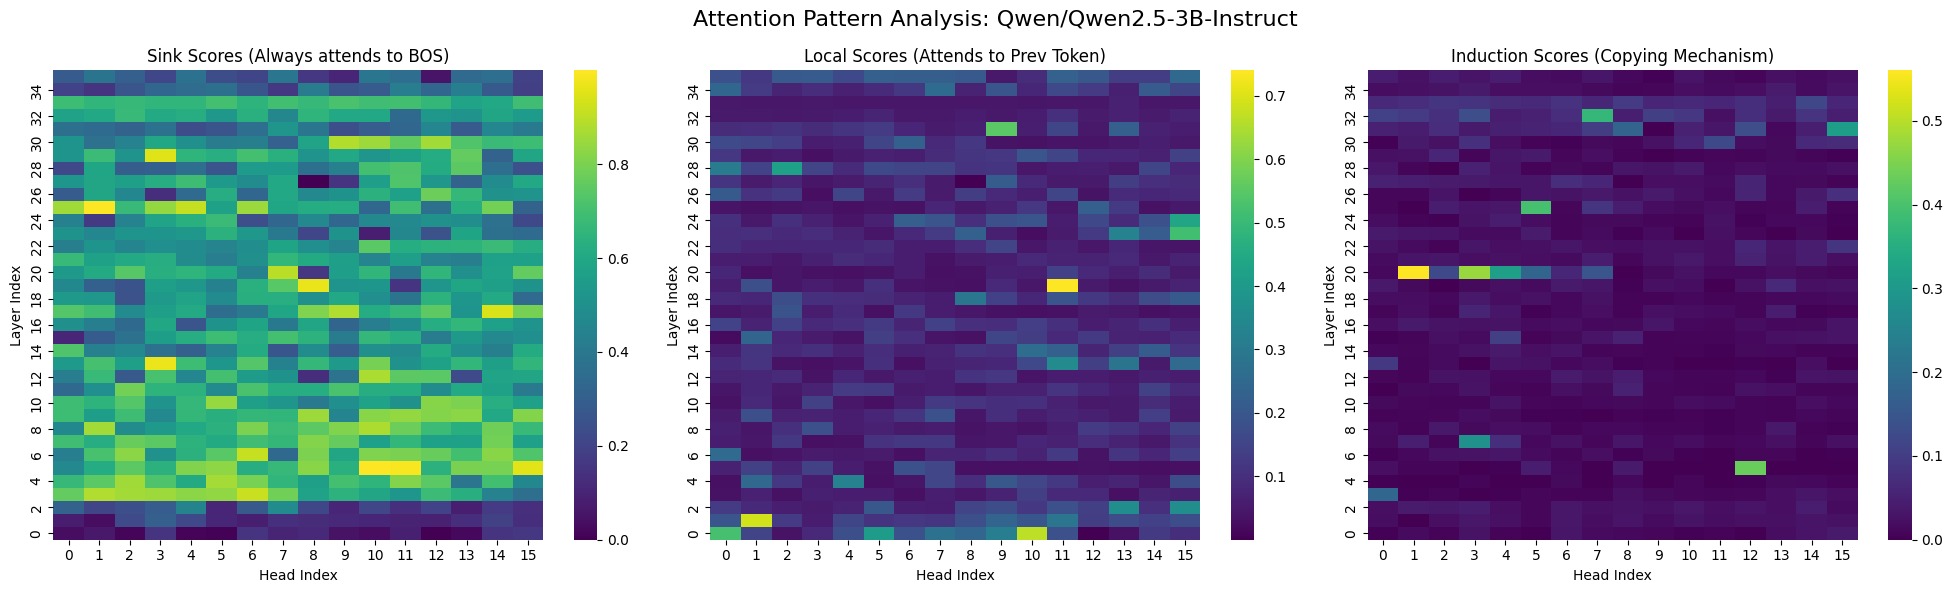

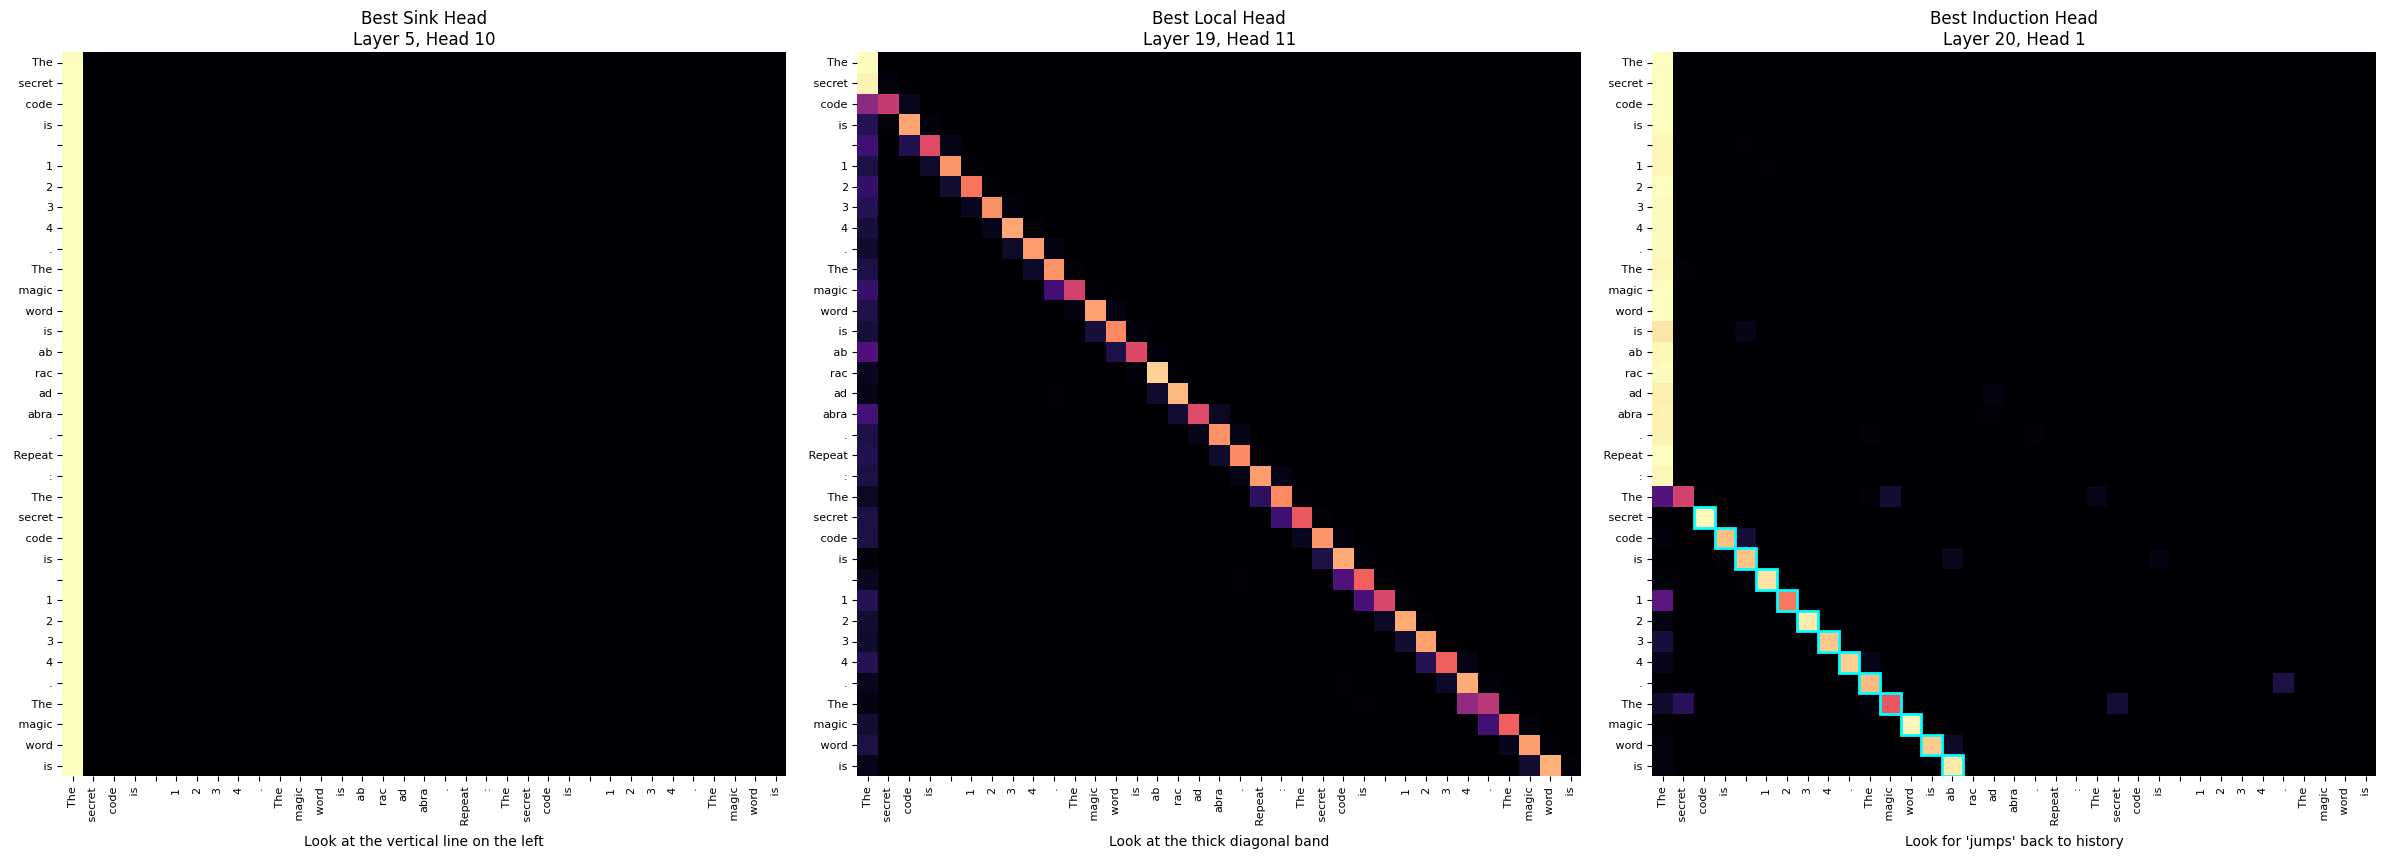

In [2]:
analyze_and_visualize_all()